# PRIMERA PARTE (IMPORTACION DE LIBRERIAS)


En esta parte importamos las librerias necesarias para poder realizar nuestra practica sin ningun tipo de problema.


A continuacion, vamos a hacer un pequeño resumen para explicar para que sirven las librerias que usamos:


* ***OS:*** Sirve para trabajar con rutas de archivos y carpetas.


* ***NUMPY:*** Se usa para trabajar con arrays y operaciones matemáticas.


* ***MATPLOITLIB:*** Sirve para visualizar imágenes del dataset y comprobar que todo se carga correctamente.


* ***RANDOM:*** Se usa para reproducibilidad o para seleccionar imágenes aleatorias.


* ***TENSORFLOW / KERAS:*** Es el framework de deep learning que usaremos para construir la CNN.


* ***KERAS:*** Es la API de alto nivel de TensorFlow para construir redes neuronales.


* ***LAYERS:*** Nos permite definir capas como:

    - Conv2D

    - MaxPooling

    - Dense

    - Dropout

   que usaremos en la CNN.


In [ ]:
# Descarga de librerías necesarias para el proyecto
%pip install tensorflow matplotlib numpy os
%pip install --upgrade tensorflow

# Importación de librerías necesarias para el proyecto
import os
import numpy as np
import matplotlib.pyplot as plt
import random

# Importación de TensorFlow y Keras para la construcción del modelo de aprendizaje profundo
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Importación de la función para cargar las imágenes desde un directorio
from tensorflow.keras.utils import image_dataset_from_directory

# Importación de la función para contar elementos en una lista
from collections import Counter

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


#PARTE 2 (SUBIR LA CARPETA CON LOS ARCHIVOS DE KEEGLE)



In [ ]:
!pip install kagglehub

import kagglehub

path = kagglehub.dataset_download("samithsachidanandan/human-face-emotions")

print("Dataset descargado en:", path)

Using Colab cache for faster access to the 'human-face-emotions' dataset.
Dataset descargado en: /kaggle/input/human-face-emotions


## Comprobamos que se ha descargado el contenido de manera correcta

In [ ]:
import os

dataset_path = os.path.join(path, "Data")

print("Clases detectadas:")
print(os.listdir(dataset_path))

Clases detectadas:
['Fear', 'Suprise', 'Angry', 'Sad', 'Happy']


# PARTE 3 (CONFIGURACION INICIAL)

* ***SEED:*** Garantiza reproducibilidad. Esto significa que si ejecutamos el entrenamiento varias veces obtendremos resultados comparables.


* ***IMG_SIZE:*** Define el tamaño al que se redimensionarán todas las imágenes. Las CNN necesitan que todas las imágenes tengan la misma dimensión. Lo ponemos a 64x64 ya que si no las imagenes serian muy pesadas para su razonamiento.


* ***BATCH_SIZE:*** Define cuántas imágenes procesa la red en cada iteración de entrenamiento. Lo ponemos a 32 ya que asi nuestro modelo no aprende de manera lenta ni de manera muy rapida.

In [ ]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Tamaño de imagen para la CNN
IMG_SIZE = (128, 128)

# Tamaño de lote
BATCH_SIZE = 32

# Carga del dataset para entrenamiento

El dataset se divide en dos subconjuntos: entrenamiento y validación, utilizando un 80% de los datos para entrenar el modelo y un 20% para evaluar su rendimiento. Esta separación es esencial para poder medir la capacidad de generalización del modelo, es decir, su habilidad para funcionar correctamente con datos que no ha visto durante el entrenamiento.

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 59099 files belonging to 5 classes.
Using 47280 files for training.
Found 59099 files belonging to 5 classes.
Using 11819 files for validation.


#Comprobamos que se han detectado bien las clases del dataset

In [ ]:
class_names = train_dataset.class_names
print("Clases detectadas por Keras:", class_names)
print("Número de clases:", len(class_names))

Clases detectadas por Keras: ['Angry', 'Fear', 'Happy', 'Sad', 'Suprise']
Número de clases: 5


#Vemos la forma que tiene nuestro dataset

Las imágenes se agrupan en lotes (batches) de tamaño 32, lo que permite procesar múltiples imágenes de forma simultánea durante el entrenamiento.

In [ ]:
for images, labels in train_dataset.take(1):
    print("Shape de imágenes:", images.shape)
    print("Shape de etiquetas:", labels.shape)
    print("Primeras etiquetas del batch:", labels[:10].numpy())

Shape de imágenes: (32, 128, 128, 1)
Shape de etiquetas: (32,)
Primeras etiquetas del batch: [0 2 3 3 1 3 1 1 2 3]


#Visualizacion de imagenes del dataset

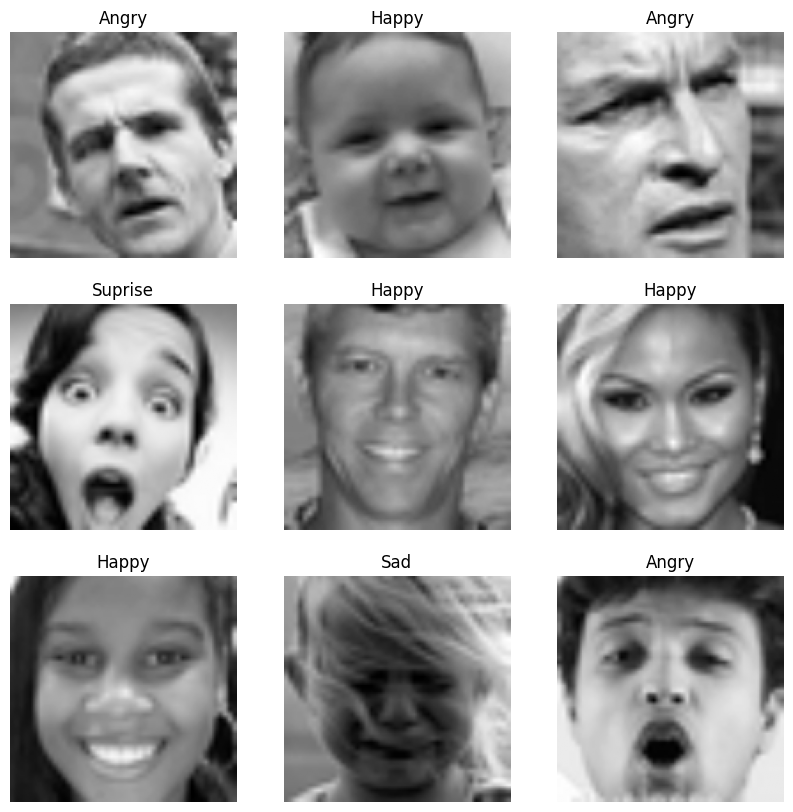

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

#PREPROCESADO DE DATOS
**Normalización**

En esta parte se realiza el preprocesado de las imágenes antes de entrenar la red neuronal convolucional. En primer lugar, se normalizan los valores de los píxeles para transformarlos del rango original [0,255] al intervalo [0,1]. Esta transformación es importante porque facilita el entrenamiento de la red, mejora la estabilidad numérica y ayuda a que el proceso de optimización converja de forma más eficiente.

**Data augmentation**

Se define una estrategia de aumento de datos (data augmentation) aplicada únicamente al conjunto de entrenamiento. Esta técnica consiste en generar variaciones leves de las imágenes originales, como giros pequeños, reflejos horizontales o cambios de escala. El objetivo es hacer que el modelo sea más robusto y capaz de generalizar mejor, reduciendo el riesgo de sobreajuste.

**Optimización del pipeline**

se optimiza la carga de datos utilizando operaciones como cache, shuffle y prefetch. Esto permite que el entrenamiento sea más eficiente, ya que mejora el flujo de lectura de imágenes y reduce tiempos de espera durante la alimentación de datos al modelo.

In [ ]:
# Capa de normalización: convierte los píxeles de [0,255] a [0,1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
#Comprobamos que se han normalizado bien las variables
for images, labels in train_dataset.take(1):
    print("Valor mínimo de píxel:", tf.reduce_min(images).numpy())
    print("Valor máximo de píxel:", tf.reduce_max(images).numpy())

Valor mínimo de píxel: 0.0
Valor máximo de píxel: 1.0


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

#Visualizacion de imagenes despues de normalizar

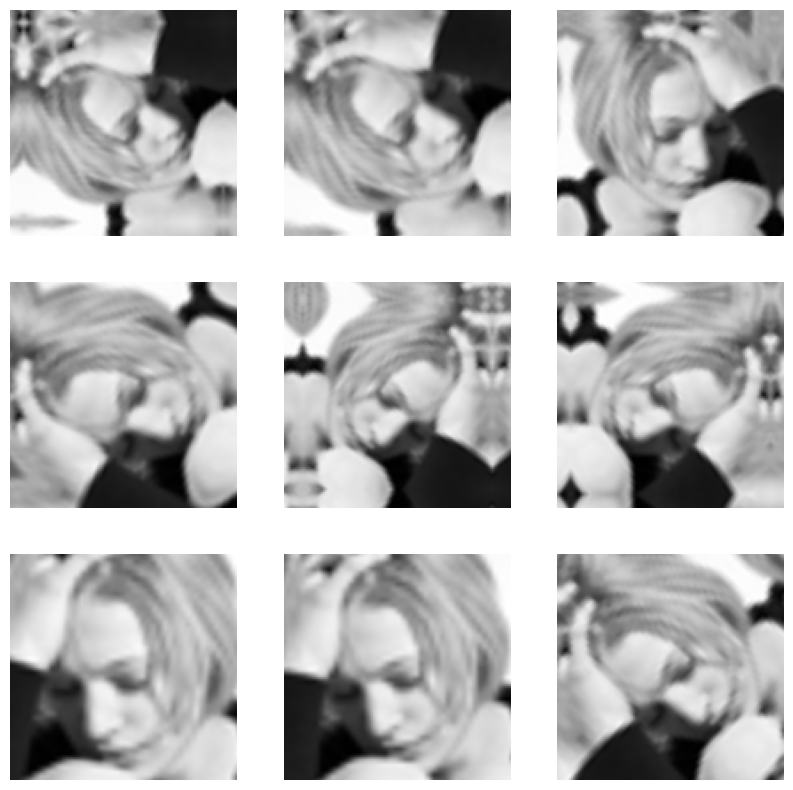

In [ ]:
plt.figure(figsize=(10, 10))

for images, _ in train_dataset.take(1):
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0].numpy().squeeze(), cmap="gray")
        plt.axis("off")

plt.show()

#Optimizamos el pipeline para mejorar el entrenamiento y la rapidez

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# APARTADO 2 (EJERCICIO 1)
En esta sección se implementa una primera arquitectura base de red neuronal convolucional utilizando Keras.

La arquitectura propuesta incluye varias capas convolucionales para extraer características espaciales de las imágenes, capas de pooling para reducir dimensionalidad y una parte final completamente conectada para realizar la clasificación.
Se utiliza la función de activación ReLU en las capas ocultas, ya que favorece un entrenamiento eficiente, y softmax en la capa de salida para obtener probabilidades asociadas a cada una de las cinco clases.

El modelo se compila utilizando el optimizador Adam y la función de pérdida sparse_categorical_crossentropy, adecuada para problemas de clasificación multiclase cuando las etiquetas están codificadas como enteros.

#CREAMOS UN CASO BASE PARA NUESTRA CNN

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 1)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 1)),

    # Aumento de datos
    data_augmentation,

    # Bloque convolucional 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Bloque convolucional 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Bloque convolucional 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Clasificación
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [ ]:
model_1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,829 (429.02 KB)

 Trainable params: 109,829 (429.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_1 = model_1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 196s 65ms/step - accuracy: 0.3144 - loss: 1.5495 - val_accuracy: 0.3213 - val_loss: 1.5370
Epoch 2/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.3232 - loss: 1.5304 - val_accuracy: 0.3412 - val_loss: 1.5131
Epoch 3/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.3367 - loss: 1.5107 - val_accuracy: 0.3578 - val_loss: 1.4812
Epoch 4/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.3565 - loss: 1.4824 - val_accuracy: 0.3706 - val_loss: 1.4547
Epoch 5/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.3775 - loss: 1.4457 - val_accuracy: 0.3998 - val_loss: 1.4010
Epoch 6/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.3947 - loss: 1.4159 - val_accuracy: 0.4071 - val_loss: 1.3922
Epoch 7/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.4079 - loss: 1.3899 - val_accuracy: 0.4285 - val_loss: 1.3543
Epoch 8/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.4204 

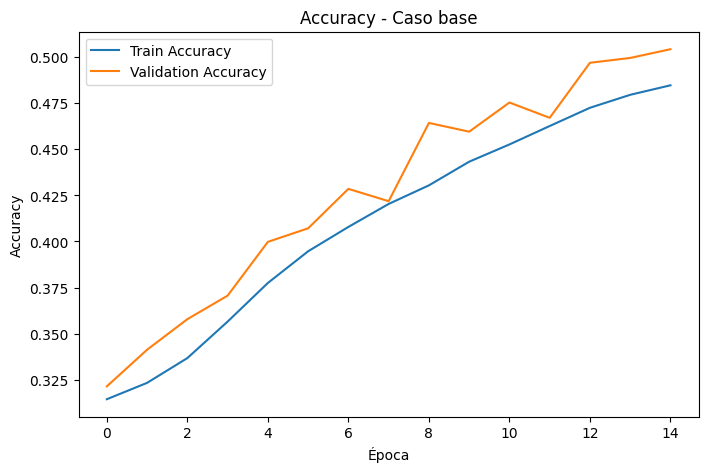

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy - Caso base')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

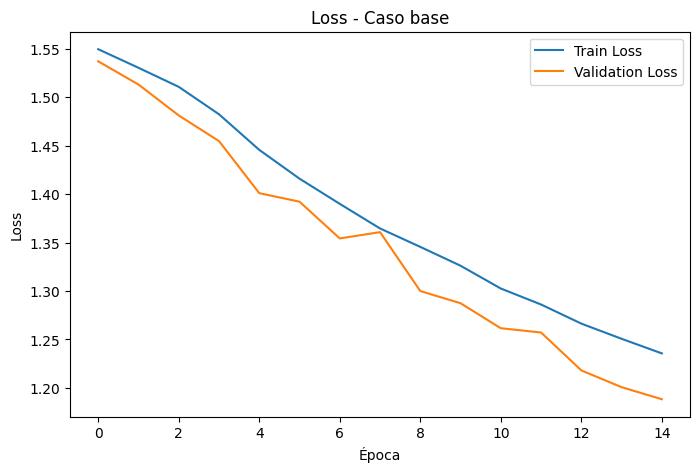

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('Loss - Caso base')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

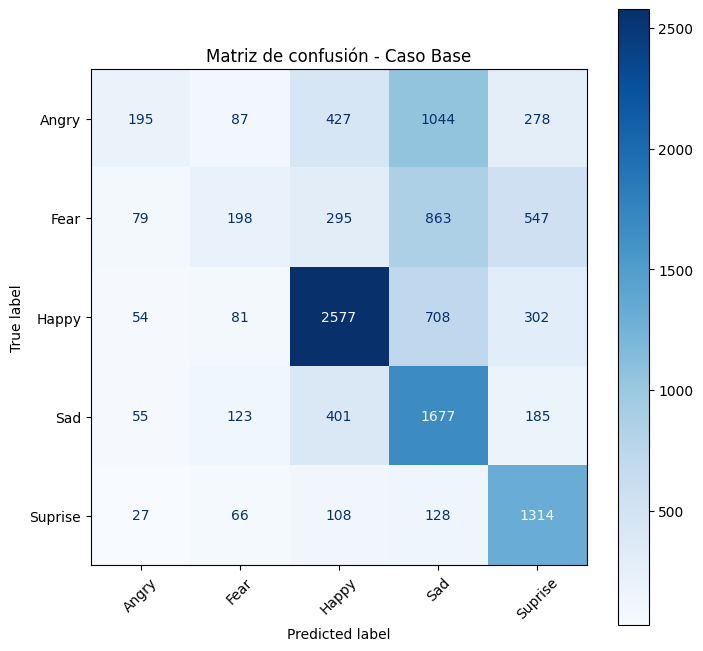

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model_1.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Caso Base")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/IAII_modelos"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Carpeta de guardado:", SAVE_DIR)

In [ ]:
MODEL_PATH_1 = os.path.join(SAVE_DIR, "model_1_final.keras")

model_1.save(MODEL_PATH_1)

print("Modelo guardado en:", MODEL_PATH_1)

In [ ]:
import json

HISTORY_PATH_1 = os.path.join(SAVE_DIR, "history_1.json")

with open(HISTORY_PATH_1, "w") as f:
    json.dump(history_1.history, f)

print("Historial guardado en:", HISTORY_PATH_1)

#CASO BASE 2


In [ ]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 1)),

    # Aumento de datos
    data_augmentation,

    # Bloque convolucional 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Bloque convolucional 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Bloque convolucional 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Clasificación
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [ ]:
model_3.summary()

In [ ]:
model_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping_2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_2 = model_3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stopping_2]
)

Epoch 1/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 62s 42ms/step - accuracy: 0.6137 - loss: 0.9528 - val_accuracy: 0.6283 - val_loss: 0.9240
Epoch 2/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 61s 42ms/step - accuracy: 0.6208 - loss: 0.9440 - val_accuracy: 0.6410 - val_loss: 0.9046
Epoch 3/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 63s 42ms/step - accuracy: 0.6265 - loss: 0.9307 - val_accuracy: 0.6402 - val_loss: 0.8992
Epoch 4/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.6309 - loss: 0.9209 - val_accuracy: 0.6504 - val_loss: 0.8744
Epoch 5/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.6348 - loss: 0.9123 - val_accuracy: 0.6487 - val_loss: 0.8791
Epoch 6/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.6363 - loss: 0.9113 - val_accuracy: 0.6493 - val_loss: 0.8730
Epoch 7/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 63s 43ms/step - accuracy: 0.6422 - loss: 0.8988 - val_accuracy: 0.6566 - val_loss: 0.8579
Epoch 8/15
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.6433 -

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy - Configuración alternativa (6 capas convolucionales)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy - Configuración alternativa (6 capas convolucionales)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model_3.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Caso 2")
plt.show()

In [ ]:
best_val_acc_1 = max(history_1.history['val_accuracy'])
best_val_acc_2 = max(history_2.history['val_accuracy'])

best_val_loss_1 = min(history_1.history['val_loss'])
best_val_loss_2 = min(history_2.history['val_loss'])

print("Caso base - mejor val_accuracy:", best_val_acc_1)
print("Configuración alternativa - mejor val_accuracy:", best_val_acc_2)
print()
print("Caso base - mejor val_loss:", best_val_loss_1)
print("Configuración alternativa - mejor val_loss:", best_val_loss_2)

#CASO 3

In [ ]:
model_4 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 1)),

    # Data augmentation
    data_augmentation,

    # Bloque 1
    tf.keras.layers.Conv2D(32, (5, 5), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Bloque 2
    tf.keras.layers.Conv2D(64, (5, 5), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Bloque 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Clasificación
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [ ]:
model_4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,081 (3.33 MB)

 Trainable params: 290,693 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 581,388 (2.22 MB)

In [ ]:
model_4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping_4 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_4 = model_4.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stopping_4]
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_4.history['accuracy'], label='Train Accuracy')
plt.plot(history_4.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy - Caso 4')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

NameError: name 'history_4' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_4.history['loss'], label='Train Loss')
plt.plot(history_4.history['val_loss'], label='Validation Loss')
plt.title('Loss - Caso 4')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model_4.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Caso 4")
plt.show()

In [ ]:
best_val_acc_1 = max(history_1.history['val_accuracy'])
best_val_acc_4 = max(history_4.history['val_accuracy'])

best_val_loss_1 = min(history_1.history['val_loss'])
best_val_loss_4 = min(history_4.history['val_loss'])

print("Caso base - mejor val_accuracy:", best_val_acc_1)
print("Caso 4    - mejor val_accuracy:", best_val_acc_4)
print()
print("Caso base - mejor val_loss:", best_val_loss_1)
print("Caso 4    - mejor val_loss:", best_val_loss_4)

#CONFIGURACION BASANDONOS EN LAS ANTERIORES

In [ ]:
model_5 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 1)),

    # Data augmentation
    data_augmentation,

    # Bloque 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Bloque 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Bloque 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Clasificación
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [ ]:
model_5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping_5 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history_5 = model_5.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stopping_5]
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_5.history['accuracy'], label='Train Accuracy')
plt.plot(history_5.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy - Caso 5')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_5.history['loss'], label='Train Loss')
plt.plot(history_5.history['val_loss'], label='Validation Loss')
plt.title('Loss - Caso 5')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model_5.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Caso 5")
plt.show()

In [ ]:
best_val_acc_2 = max(history_2.history['val_accuracy'])
best_val_acc_5 = max(history_5.history['val_accuracy'])

best_val_loss_2 = min(history_2.history['val_loss'])
best_val_loss_5 = min(history_5.history['val_loss'])

print("Caso 2 - mejor val_accuracy:", best_val_acc_2)
print("Caso 5 - mejor val_accuracy:", best_val_acc_5)
print()
print("Caso 2 - mejor val_loss:", best_val_loss_2)
print("Caso 5 - mejor val_loss:", best_val_loss_5)

#NUEVO CASO DESPUES DE HABLAR CON MARLON

In [ ]:
data_augmentation_6 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation_6")

In [ ]:
model_6 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),

    data_augmentation_6,

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [ ]:
model_6.summary()

In [ ]:
model_6.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping_6 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

In [ ]:
history_6 = model_6.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=60,
    callbacks=[early_stopping_6]
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_6.history['accuracy'], label='Train Accuracy')
plt.plot(history_6.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy - Caso 6')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_6.history['loss'], label='Train Loss')
plt.plot(history_6.history['val_loss'], label='Validation Loss')
plt.title('Loss - Caso 6')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model_6.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Caso 6")
plt.show()

In [ ]:
best_val_acc_5 = max(history_5.history['val_accuracy'])
best_val_acc_6 = max(history_6.history['val_accuracy'])

best_val_loss_5 = min(history_5.history['val_loss'])
best_val_loss_6 = min(history_6.history['val_loss'])

print("Caso 5 - mejor val_accuracy:", best_val_acc_5)
print("Caso 6 - mejor val_accuracy:", best_val_acc_6)
print()
print("Caso 5 - mejor val_loss:", best_val_loss_5)
print("Caso 6 - mejor val_loss:", best_val_loss_6)

#Entorno de ejecucion 7

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [ ]:
for images, labels in train_dataset.take(1):
    print("Shape imágenes:", images.shape)
    print("Shape labels:", labels.shape)

In [ ]:
data_augmentation_7 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 1)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomTranslation(height_factor=0.02, width_factor=0.02),
    tf.keras.layers.RandomZoom(0.04),
], name="data_augmentation_7")

In [ ]:
tf.keras.backend.clear_session()

model_7 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 1)),

    data_augmentation_7,

    # Bloque 1
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(32, (3, 3), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.10),

    # Bloque 2
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(64, (3, 3), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.15),

    # Bloque 3
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(128, (3, 3), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.20),

    # Bloque 4
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Conv2D(256, (3, 3), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Cabeza de clasificación
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.35),

    tf.keras.layers.Dense(128, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(5, activation='softmax')
])

In [ ]:
model_7.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stopping_7 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_7 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
import os

counts = {clase: len(os.listdir(os.path.join(dataset_path, clase))) for clase in class_names}
total = sum(counts.values())
num_classes = len(counts)

class_weight = {}
for i, clase in enumerate(class_names):
    class_weight[i] = total / (num_classes * counts[clase])

print("Pesos por clase:", class_weight)

In [ ]:
history_7 = model_7.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=80,
    callbacks=[early_stopping_7, reduce_lr_7],
    class_weight=class_weight
)

In [ ]:
model_7.summary()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_7.history['accuracy'], label='Train Accuracy')
plt.plot(history_7.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy - Caso 7')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_7.history['loss'], label='Train Loss')
plt.plot(history_7.history['val_loss'], label='Validation Loss')
plt.title('Loss - Caso 7')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model_7.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Caso 7")
plt.show()

In [ ]:
# =========================================
# GUARDAR MODELO FINAL, HISTORIAL Y METADATOS
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import pickle
import tensorflow as tf

# Carpeta de guardado en Drive
save_dir = "/content/drive/MyDrive/IAII_modelos/modelo_final_7"
os.makedirs(save_dir, exist_ok=True)

# 1) Guardar el modelo completo (.keras)
model_7.save(os.path.join(save_dir, "model_7_final.keras"))

# 2) Guardar historial de entrenamiento
with open(os.path.join(save_dir, "history_7.pkl"), "wb") as f:
    pickle.dump(history_7.history, f)

# 3) Guardar metadatos útiles
metadata = {
    "class_names": list(class_names),
    "IMG_SIZE": list(IMG_SIZE),
    "BATCH_SIZE": int(BATCH_SIZE)
}

with open(os.path.join(save_dir, "metadata_7.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print("Modelo final guardado correctamente en:")
print(save_dir)

In [ ]:
# =========================================
# CARGAR MODELO FINAL, HISTORIAL Y METADATOS
# =========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import pickle
import tensorflow as tf

save_dir = "/content/drive/MyDrive/IAII_modelos/modelo_final_7"

# 1) Cargar modelo
model_7 = tf.keras.models.load_model(os.path.join(save_dir, "model_7_final.keras"))

# 2) Cargar historial
with open(os.path.join(save_dir, "history_7.pkl"), "rb") as f:
    history_7_dict = pickle.load(f)

# 3) Cargar metadatos
with open(os.path.join(save_dir, "metadata_7.json"), "r", encoding="utf-8") as f:
    metadata_7 = json.load(f)

class_names = metadata_7["class_names"]
IMG_SIZE = tuple(metadata_7["IMG_SIZE"])
BATCH_SIZE = metadata_7["BATCH_SIZE"]

print("Modelo cargado correctamente")
print("Clases:", class_names)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)

In [ ]:
# =========================================
# DATASET DE EVALUACIÓN DEL MODELO FINAL
# =========================================

# Si ya tienes test_dataset, usa esta línea:
# eval_dataset = test_dataset

# Si todavía no has creado test_dataset, usa validación:
eval_dataset = val_dataset

print("Dataset de evaluación preparado")

In [ ]:
# =========================================
# UNIFICAR HISTORIAL
# =========================================

if "history_7" in globals():
    hist_final = history_7.history
elif "history_7_dict" in globals():
    hist_final = history_7_dict
else:
    raise ValueError("No se ha encontrado ni history_7 ni history_7_dict")

print("Historial listo para gráficas")

In [ ]:
# =========================================
# GRÁFICA DE ACCURACY
# =========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(hist_final['accuracy'], label='Train Accuracy')
plt.plot(hist_final['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy - Modelo final')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# =========================================
# GRÁFICA DE LOSS
# =========================================

plt.figure(figsize=(8,5))
plt.plot(hist_final['loss'], label='Train Loss')
plt.plot(hist_final['val_loss'], label='Validation Loss')
plt.title('Loss - Modelo final')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# =========================================
# PREPARAR PREDICCIONES DEL MODELO FINAL
# =========================================

import numpy as np

y_true = []
y_pred = []
y_probs = []
images_all = []
labels_all = []

for images, labels in eval_dataset:
    preds = model_7.predict(images, verbose=0)
    preds_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)
    y_probs.extend(preds)
    images_all.extend(images.numpy())
    labels_all.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)
images_all = np.array(images_all)
labels_all = np.array(labels_all)

print("Número total de imágenes evaluadas:", len(y_true))

In [ ]:
# =========================================
# MATRIZ DE CONFUSIÓN ABSOLUTA
# =========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Modelo final")
plt.show()

In [ ]:
# =========================================
# MATRIZ DE CONFUSIÓN NORMALIZADA
# =========================================

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", xticks_rotation=45)
plt.title("Matriz de confusión normalizada - Modelo final")
plt.show()

In [ ]:
# =========================================
# PRECISION, RECALL Y F1-SCORE POR CLASE
# =========================================

import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

metricas_df = pd.DataFrame({
    "Precision": [report[cl]["precision"] for cl in class_names],
    "Recall":    [report[cl]["recall"] for cl in class_names],
    "F1-score":  [report[cl]["f1-score"] for cl in class_names]
}, index=class_names)

metricas_df.plot(kind="bar", figsize=(10,6))
plt.title("Precision, Recall y F1-score por clase - Modelo final")
plt.xlabel("Clase")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

print(metricas_df)

In [ ]:
# =========================================
# TOP 3 CATEGORÍAS PARA UNA IMAGEN
# =========================================

idx = 0  # cambia este índice si quieres otra imagen

image = images_all[idx]
true_label = class_names[int(labels_all[idx])]
probs = y_probs[idx]

top3_idx = np.argsort(probs)[::-1][:3]
top3_classes = [class_names[i] for i in top3_idx]
top3_probs = [probs[i] for i in top3_idx]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Etiqueta real: {true_label}")
plt.axis("off")

plt.subplot(1,2,2)
plt.bar(top3_classes, top3_probs)
plt.title("Top 3 categorías predichas")
plt.ylabel("Probabilidad")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

print("Top 3 predicciones:")
for clase, prob in zip(top3_classes, top3_probs):
    print(f"{clase}: {prob:.4f}")

In [ ]:
# =========================================
# PROBABILIDADES COMPLETAS POR CLASE
# =========================================

idx = 0  # usa el mismo índice o cámbialo

image = images_all[idx]
true_label = class_names[int(labels_all[idx])]
probs = y_probs[idx]

order = np.argsort(probs)[::-1]
ordered_classes = [class_names[i] for i in order]
ordered_probs = probs[order]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Etiqueta real: {true_label}")
plt.axis("off")

plt.subplot(1,2,2)
plt.bar(ordered_classes, ordered_probs)
plt.title("Probabilidades por clase")
plt.ylabel("Probabilidad")
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# EJEMPLOS DE PREDICCIONES CORRECTAS
# =========================================

correct_idx = np.where(y_true == y_pred)[0][:6]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(correct_idx):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images_all[idx].squeeze(), cmap="gray")
    real = class_names[int(y_true[idx])]
    pred = class_names[int(y_pred[idx])]
    prob = np.max(y_probs[idx])
    plt.title(f"Real: {real}\nPred: {pred}\nProb: {prob:.2f}")
    plt.axis("off")

plt.suptitle("Ejemplos de predicciones correctas")
plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# EJEMPLOS DE PREDICCIONES INCORRECTAS
# =========================================

incorrect_idx = np.where(y_true != y_pred)[0][:6]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(incorrect_idx):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images_all[idx].squeeze(), cmap="gray")
    real = class_names[int(y_true[idx])]
    pred = class_names[int(y_pred[idx])]
    prob = np.max(y_probs[idx])
    plt.title(f"Real: {real}\nPred: {pred}\nProb: {prob:.2f}")
    plt.axis("off")

plt.suptitle("Ejemplos de predicciones incorrectas")
plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# EVOLUCIÓN DEL LEARNING RATE
# =========================================

if "learning_rate" in hist_final:
    plt.figure(figsize=(8,5))
    plt.plot(hist_final["learning_rate"])
    plt.title("Evolución del learning rate")
    plt.xlabel("Época")
    plt.ylabel("Learning rate")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No se ha encontrado 'learning_rate' en el historial")

In [ ]:
# =========================================
# RESUMEN NUMÉRICO FINAL
# =========================================

from sklearn.metrics import accuracy_score

print("Accuracy global:", accuracy_score(y_true, y_pred))
print("Mejor val_accuracy:", max(hist_final["val_accuracy"]))
print("Mejor val_loss:", min(hist_final["val_loss"]))
print("Época con mejor val_loss:", np.argmin(hist_final["val_loss"]) + 1)